<a href="https://colab.research.google.com/github/machiwao/CCRNFLRL_Integer_Damath/blob/eco/Damath_hehe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
import matplotlib.pyplot as plt
from copy import deepcopy
import pandas as pd

In [2]:
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

In [3]:
class IntegerDamathEnv:
    """
    Integer Damath Environment (Grade 7 variant)
    Combines checkers movement with arithmetic operations
    """
    def __init__(self):
        self.board_size = 8
        self.move_history = []
        self.reset()

        # Fixed Damath board template
        self.initial_board_template = [
            [2, "#", -5, "#", 8, "#", -11, "#"],
            ["#", -7, "#", 10, "#", -3, "#", 0],
            [4, "#", -1, "#", 9, "#", -6, "#"],
            ["#", "#", "#", "#", "#", "#", "#", "#"],
            ["#", "#", "#", "#", "#", "#", "#", "#"],
            ["#", -9, "#", 6, "#", -1, "#", 4],
            [0, "#", -3, "#", 10, "#", -7, "#"],
            ["#", -11, "#", 8, "#", -5, "#", 2]
        ]

        # Operations board
        self.operations_board = [
            ["+", "#", "÷", "#", "-", "#", "×", "#"],
            ["#", "×", "#", "+", "#", "÷", "#", "-"],
            ["-", "#", "+", "#", "÷", "#", "×", "#"],
            ["#", "÷", "#", "-", "#", "×", "#", "+"],
            ["×", "#", "÷", "#", "-", "#", "+", "#"],
            ["#", "+", "#", "÷", "#", "-", "#", "×"],
            ["÷", "#", "×", "#", "+", "#", "-", "#"],
            ["#", "-", "#", "×", "#", "+", "#", "÷"],
        ]

    def reset(self):
        """Reset the game to initial state"""
        self.board = np.zeros((8, 8), dtype=object)
        self.piece_types = np.zeros((8, 8), dtype=int)  # 0: empty, 1: regular, 2: dama
        self.move_history = []

        # Initialize pieces for Player 1 (top, moving down)
        player1_positions = [
            (0, 0, 2), (0, 2, -5), (0, 4, 8), (0, 6, -11),
            (1, 1, -7), (1, 3, 10), (1, 5, -3), (1, 7, 0),
            (2, 0, 4), (2, 2, -1), (2, 4, 9), (2, 6, -6)
        ]

        # Initialize pieces for Player 2 (bottom, moving up)
        player2_positions = [
            (5, 1, -9), (5, 3, 6), (5, 5, -1), (5, 7, 4),
            (6, 0, 0), (6, 2, -3), (6, 4, 10), (6, 6, -7),
            (7, 1, -11), (7, 3, 8), (7, 5, -5), (7, 7, 2)
        ]

        for r, c, val in player1_positions:
            self.board[r, c] = (1, val)  # (player, value)
            self.piece_types[r, c] = 1

        for r, c, val in player2_positions:
            self.board[r, c] = (2, val)  # (player, value)
            self.piece_types[r, c] = 1

        self.current_player = 1
        self.scores = {1: 0, 2: 0}
        self.game_over = False
        self.winner = None
        self.moves_without_capture = 0
        self.max_moves_without_capture = 50

        return self.get_state()

    def get_state(self):
        """Convert board to state representation for neural network"""
        # Create separate channels for player 1, player 2, damas, and values
        state = np.zeros((6, 8, 8), dtype=np.float32)

        for r in range(8):
            for c in range(8):
                if self.board[r, c] != 0:
                    player, value = self.board[r, c]
                    if player == 1:
                        state[0, r, c] = 1  # Player 1 pieces
                        state[2, r, c] = value / 11.0  # Normalized value
                    else:
                        state[1, r, c] = 1  # Player 2 pieces
                        state[3, r, c] = value / 11.0  # Normalized value

                    if self.piece_types[r, c] == 2:
                        state[4, r, c] = 1  # Dama pieces

        # Current player indicator
        state[5, :, :] = self.current_player

        return state

    def get_legal_moves(self, player=None):
        """Get all legal moves for the current player"""
        if player is None:
            player = self.current_player

        moves = []
        mandatory_captures = []

        for r in range(8):
            for c in range(8):
                if self.board[r, c] != 0 and self.board[r, c][0] == player:
                    piece_moves = self._get_piece_moves(r, c)
                    for move in piece_moves:
                        if move['is_capture']:
                            mandatory_captures.append(move)
                        else:
                            moves.append(move)

        # In Damath, captures are mandatory if available
        return mandatory_captures if mandatory_captures else moves

    def _get_piece_moves(self, r, c):
        """Get all legal moves for a piece at position (r, c)"""
        moves = []
        player, value = self.board[r, c]
        is_dama = self.piece_types[r, c] == 2

        # Direction based on player and piece type
        if is_dama:
            directions = [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        else:
            directions = [(-1, -1), (-1, 1)] if player == 2 else [(1, -1), (1, 1)]

        for dr, dc in directions:
            # Simple move
            nr, nc = r + dr, c + dc
            if 0 <= nr < 8 and 0 <= nc < 8 and self.board[nr, nc] == 0:
                moves.append({
                    'from': (r, c),
                    'to': (nr, nc),
                    'is_capture': False,
                    'captured_pos': None,
                    'score': 0
                })

            # Capture move
            nr, nc = r + dr, c + dc
            jump_r, jump_c = r + 2*dr, c + 2*dc
            if (0 <= nr < 8 and 0 <= nc < 8 and
                0 <= jump_r < 8 and 0 <= jump_c < 8 and
                self.board[nr, nc] != 0 and
                self.board[nr, nc][0] != player and
                self.board[jump_r, jump_c] == 0):

                # Calculate score for this capture
                captured_value = self.board[nr, nc][1]
                operation = self.operations_board[nr][nc]
                score = self._calculate_score(value, captured_value, operation)

                moves.append({
                    'from': (r, c),
                    'to': (jump_r, jump_c),
                    'is_capture': True,
                    'captured_pos': (nr, nc),
                    'score': score
                })

        return moves

    def _calculate_score(self, attacker_val, defender_val, operation):
        """Calculate score based on arithmetic operation"""
        try:
            if operation == '+':
                return attacker_val + defender_val
            elif operation == '-':
                return attacker_val - defender_val
            elif operation == '×':
                return attacker_val * defender_val
            elif operation == '÷':
                if defender_val != 0:
                    return int(attacker_val / defender_val)
                return 0
        except:
            return 0
        return 0

    def step(self, move, record_move=True):
        """Execute a move and return (next_state, reward, done, info)"""
        if self.game_over:
            return self.get_state(), 0, True, {}

        from_pos = move['from']
        to_pos = move['to']
        is_capture = move['is_capture']

        # Record move details before execution
        move_record = {
            'step': len(self.move_history) + 1,
            'player': self.current_player,
            'from': from_pos,
            'to': to_pos,
            'piece_value': self.board[from_pos][1],
            'is_dama': self.piece_types[from_pos] == 2,
            'is_capture': is_capture,
            'captured_value': None,
            'operation': None,
            'arithmetic_score': 0,
            'reward': 0,
            'promoted': False,
            'score_before': self.scores.copy(),
            'score_after': None
        }

        # Move the piece
        player, value = self.board[from_pos]
        piece_type = self.piece_types[from_pos]

        self.board[to_pos] = self.board[from_pos]
        self.piece_types[to_pos] = piece_type
        self.board[from_pos] = 0
        self.piece_types[from_pos] = 0

        reward = 0

        # Handle capture
        if is_capture:
            captured_pos = move['captured_pos']
            captured_value = self.board[captured_pos][1]
            operation = self.operations_board[captured_pos[0]][captured_pos[1]]

            move_record['captured_value'] = captured_value
            move_record['operation'] = operation

            self.board[captured_pos] = 0
            self.piece_types[captured_pos] = 0

            score = move['score']
            self.scores[player] += score
            reward = score
            move_record['arithmetic_score'] = score

            # Bonus for dama capture
            if piece_type == 2:
                reward += 2
                move_record['dama_bonus'] = 2

            self.moves_without_capture = 0
        else:
            self.moves_without_capture += 1

        # Check for promotion to dama
        if player == 1 and to_pos[0] == 7 and piece_type == 1:
            self.piece_types[to_pos] = 2
            reward += 5
            move_record['promoted'] = True
            move_record['promotion_bonus'] = 5
        elif player == 2 and to_pos[0] == 0 and piece_type == 1:
            self.piece_types[to_pos] = 2
            reward += 5
            move_record['promoted'] = True
            move_record['promotion_bonus'] = 5

        move_record['reward'] = reward
        move_record['score_after'] = self.scores.copy()

        if record_move:
            self.move_history.append(move_record)

        # Check game end conditions
        self._check_game_over()

        # Switch player
        self.current_player = 3 - self.current_player

        return self.get_state(), reward, self.game_over, {'winner': self.winner}

    def _check_game_over(self):
        """Check if the game is over"""
        # Count pieces
        p1_pieces = np.sum((self.board != 0) & (np.vectorize(lambda x: x[0] if x != 0 else 0)(self.board) == 1))
        p2_pieces = np.sum((self.board != 0) & (np.vectorize(lambda x: x[0] if x != 0 else 0)(self.board) == 2))

        # Game over if one player has no pieces
        if p1_pieces == 0:
            self.game_over = True
            self.winner = 2
            return
        if p2_pieces == 0:
            self.game_over = True
            self.winner = 1
            return

        # Game over if no legal moves
        if len(self.get_legal_moves(1)) == 0:
            self.game_over = True
            self.winner = 2
            return
        if len(self.get_legal_moves(2)) == 0:
            self.game_over = True
            self.winner = 1
            return

        # Draw if too many moves without capture
        if self.moves_without_capture >= self.max_moves_without_capture:
            self.game_over = True
            self.winner = 1 if self.scores[1] > self.scores[2] else 2
            if self.scores[1] == self.scores[2]:
                self.winner = 0  # Draw

    def print_move_history(self):
        """Print detailed move history"""
        print("\n" + "="*80)
        print("COMPLETE MOVE HISTORY")
        print("="*80)

        for move in self.move_history:
            print(f"\n{'─'*80}")
            print(f"Step {move['step']}: Player {move['player']}'s Turn")
            print(f"{'─'*80}")

            piece_type = "DAMA" if move['is_dama'] else "Regular"
            print(f"Piece: {piece_type} with value {move['piece_value']}")
            print(f"Move: {move['from']} → {move['to']}")

            if move['is_capture']:
                print(f"\n🎯 CAPTURE!")
                print(f"   Captured piece value: {move['captured_value']}")
                print(f"   Operation: {move['operation']}")
                print(f"   Calculation: {move['piece_value']} {move['operation']} {move['captured_value']} = {move['arithmetic_score']}")
                print(f"   Points earned: {move['arithmetic_score']}")
                if 'dama_bonus' in move:
                    print(f"   Dama capture bonus: +{move['dama_bonus']}")
            else:
                print(f"\n➡️  Simple move (no capture)")

            if move['promoted']:
                print(f"\n👑 PROMOTION TO DAMA!")
                print(f"   Promotion bonus: +{move['promotion_bonus']}")

            print(f"\nReward for this move: {move['reward']}")
            print(f"Scores after move - Player 1: {move['score_after'][1]} | Player 2: {move['score_after'][2]}")

        print("\n" + "="*80)
        print("END OF GAME HISTORY")
        print("="*80)

    def get_move_summary(self):
        """Get a summary dataframe of all moves"""
        if not self.move_history:
            return None

        summary = []
        for move in self.move_history:
            summary.append({
                'Step': move['step'],
                'Player': move['player'],
                'From': str(move['from']),
                'To': str(move['to']),
                'Piece_Value': move['piece_value'],
                'Type': 'Dama' if move['is_dama'] else 'Regular',
                'Action': 'Capture' if move['is_capture'] else 'Move',
                'Operation': move.get('operation', '-'),
                'Arith_Score': move['arithmetic_score'],
                'Reward': move['reward'],
                'P1_Score': move['score_after'][1],
                'P2_Score': move['score_after'][2]
            })

        return pd.DataFrame(summary)

    def render(self):
        """Print the current board state"""
        print("\n" + "="*50)
        print(f"Current Player: {self.current_player}")
        print(f"Scores - Player 1: {self.scores[1]} | Player 2: {self.scores[2]}")
        print("="*50)
        print("   0   1   2   3   4   5   6   7")

        for r in range(8):
            row_str = f"{r} "
            for c in range(8):
                if self.board[r, c] == 0:
                    row_str += " .  "
                else:
                    player, value = self.board[r, c]
                    dama = "D" if self.piece_types[r, c] == 2 else ""
                    symbol = "↓" if player == 1 else "↑"
                    row_str += f"{symbol}{value:2d}{dama} "[:4]
            print(row_str)
        print()

In [4]:
class ActorCriticNetwork(nn.Module):
    """
    Combined Actor-Critic network for Damath
    """
    def __init__(self, input_channels=6, board_size=8):
        super(ActorCriticNetwork, self).__init__()

        # Shared convolutional layers
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

        # Actor head (policy)
        self.actor_conv = nn.Conv2d(128, 64, kernel_size=1)
        self.actor_fc = nn.Linear(64 * board_size * board_size, 512)
        self.actor_out = nn.Linear(512, board_size * board_size * 4)  # from_pos + direction

        # Critic head (value)
        self.critic_conv = nn.Conv2d(128, 32, kernel_size=1)
        self.critic_fc = nn.Linear(32 * board_size * board_size, 256)
        self.critic_out = nn.Linear(256, 1)

    def forward(self, x):
        # Shared layers
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))

        # Actor
        actor = F.relu(self.actor_conv(x))
        actor = actor.view(actor.size(0), -1)
        actor = F.relu(self.actor_fc(actor))
        policy_logits = self.actor_out(actor)

        # Critic
        critic = F.relu(self.critic_conv(x))
        critic = critic.view(critic.size(0), -1)
        critic = F.relu(self.critic_fc(critic))
        value = self.critic_out(critic)

        return policy_logits, value

In [5]:
class ActorCriticAgent:
    """
    Actor-Critic Agent for Integer Damath with detailed tracking
    """
    def __init__(self, lr=0.0003, gamma=0.99, entropy_coef=0.01, name="Agent"):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.network = ActorCriticNetwork().to(self.device)
        self.optimizer = optim.Adam(self.network.parameters(), lr=lr)
        self.gamma = gamma
        self.entropy_coef = entropy_coef
        self.name = name

        self.saved_log_probs = []
        self.saved_values = []
        self.rewards = []
        self.action_history = []

    def select_action(self, state, legal_moves, training=True, verbose=False):
        """Select an action using the policy network"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)

        with torch.no_grad() if not training else torch.enable_grad():
            policy_logits, value = self.network(state_tensor)

        # Create mask for legal moves
        mask = self._create_move_mask(legal_moves)
        mask_tensor = torch.FloatTensor(mask).to(self.device)

        # Apply mask (set illegal moves to large negative number)
        masked_logits = policy_logits + (mask_tensor - 1) * 1e9

        # Sample action
        probs = F.softmax(masked_logits, dim=-1)

        if training:
            dist = torch.distributions.Categorical(probs)
            action_idx = dist.sample()
            log_prob = dist.log_prob(action_idx)
            entropy = dist.entropy()

            self.saved_log_probs.append(log_prob)
            self.saved_values.append(value)

            if verbose:
                print(f"\n{self.name} Decision Process:")
                print(f"  State value estimate: {value.item():.3f}")
                print(f"  Policy entropy: {entropy.item():.3f}")
                print(f"  Number of legal moves: {len(legal_moves)}")
        else:
            action_idx = torch.argmax(probs)
            if verbose:
                print(f"\n{self.name} Decision (Greedy):")
                print(f"  State value estimate: {value.item():.3f}")
                print(f"  Number of legal moves: {len(legal_moves)}")

        # Convert action index to move
        move = self._action_idx_to_move(action_idx.item(), legal_moves)

        # Record action
        self.action_history.append({
            'state_value': value.item(),
            'move': move,
            'num_legal_moves': len(legal_moves)
        })

        return move

    def _create_move_mask(self, legal_moves):
        """Create a binary mask for legal moves"""
        mask = np.zeros(8 * 8 * 4)
        for move in legal_moves:
            idx = self._move_to_action_idx(move)
            if idx < len(mask):
                mask[idx] = 1
        return mask

    def _move_to_action_idx(self, move):
        """Convert move to action index"""
        from_r, from_c = move['from']
        to_r, to_c = move['to']

        # Encode direction
        dr, dc = to_r - from_r, to_c - from_c
        if abs(dr) == 2:  # Capture move
            dr, dc = dr // 2, dc // 2

        direction_map = {(-1, -1): 0, (-1, 1): 1, (1, -1): 2, (1, 1): 3}
        direction = direction_map.get((dr, dc), 0)

        return from_r * 8 * 4 + from_c * 4 + direction

    def _action_idx_to_move(self, action_idx, legal_moves):
        """Convert action index back to move"""
        if len(legal_moves) == 0:
            return None

        # Find closest matching move
        best_move = legal_moves[0]
        min_diff = float('inf')

        for move in legal_moves:
            move_idx = self._move_to_action_idx(move)
            diff = abs(move_idx - action_idx)
            if diff < min_diff:
                min_diff = diff
                best_move = move

        return best_move

    def store_reward(self, reward):
        """Store reward for this step"""
        self.rewards.append(reward)

    def update(self, verbose=False):
        """Update the network using collected experience"""
        if len(self.rewards) == 0:
            return 0

        R = 0
        returns = []

        # Calculate discounted returns
        for r in reversed(self.rewards):
            R = r + self.gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns).to(self.device)
        returns_normalized = (returns - returns.mean()) / (returns.std() + 1e-8)

        policy_losses = []
        value_losses = []
        advantages = []

        for log_prob, value, R in zip(self.saved_log_probs, self.saved_values, returns):
            advantage = R - value.item()
            advantages.append(advantage)

            # Actor loss
            policy_losses.append(-log_prob * advantage)

            # Critic loss
            value_losses.append(F.smooth_l1_loss(value.squeeze(), torch.tensor([R]).to(self.device)))

        self.optimizer.zero_grad()

        total_policy_loss = torch.stack(policy_losses).sum()
        total_value_loss = torch.stack(value_losses).sum()
        loss = total_policy_loss + total_value_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.network.parameters(), 0.5)
        self.optimizer.step()

        if verbose:
            print(f"\n{self.name} Update:")
            print(f"  Total reward: {sum(self.rewards):.2f}")
            print(f"  Average return: {returns.mean().item():.2f}")
            print(f"  Average advantage: {np.mean(advantages):.3f}")
            print(f"  Policy loss: {total_policy_loss.item():.3f}")
            print(f"  Value loss: {total_value_loss.item():.3f}")
            print(f"  Total loss: {loss.item():.3f}")

        # Clear memory
        self.saved_log_probs = []
        self.saved_values = []
        self.rewards = []
        self.action_history = []

        return loss.item()

    def save(self, path):
        """Save model"""
        torch.save(self.network.state_dict(), path)

    def load(self, path):
        """Load model"""
        self.network.load_state_dict(torch.load(path))

In [6]:
def train_actor_critic(num_episodes=1000, render_every=100, verbose_episodes=None):
    """
    Train two Actor-Critic agents to play Damath against each other
    """
    env = IntegerDamathEnv()
    agent1 = ActorCriticAgent(lr=0.0003, name="Agent 1 (Player 1)")
    agent2 = ActorCriticAgent(lr=0.0003, name="Agent 2 (Player 2)")

    episode_rewards = []
    episode_lengths = []
    wins = {1: 0, 2: 0, 0: 0}

    # Episodes to show verbose output
    if verbose_episodes is None:
        verbose_episodes = []

    print("Starting Actor-Critic Training for Integer Damath")
    print("="*60)
    print(f"Device: {agent1.device}")
    print("="*60)

    for episode in range(num_episodes):
        state = env.reset()
        episode_reward = 0
        steps = 0
        verbose = episode in verbose_episodes

        if verbose:
            print(f"\n{'='*80}")
            print(f"EPISODE {episode + 1} - DETAILED PLAY-BY-PLAY")
            print(f"{'='*80}")
            env.render()

        while not env.game_over and steps < 200:
            current_agent = agent1 if env.current_player == 1 else agent2
            opponent_agent = agent2 if env.current_player == 1 else agent1

            legal_moves = env.get_legal_moves()
            if len(legal_moves) == 0:
                break

            if verbose:
                print(f"\n{'─'*80}")
                print(f"Step {steps + 1}: {current_agent.name}'s Turn")
                print(f"{'─'*80}")

            move = current_agent.select_action(state, legal_moves, training=True, verbose=verbose)

            if verbose:
                print(f"\nSelected move: {move['from']} → {move['to']}")
                if move['is_capture']:
                    print(f"  This is a CAPTURE move!")
                    print(f"  Expected score: {move['score']}")

            next_state, reward, done, info = env.step(move)

            if verbose:
                print(f"\nReward received: {reward}")
                env.render()

            # Store reward for current agent
            current_agent.store_reward(reward)
            # Opponent gets negative reward
            opponent_agent.store_reward(-reward)

            episode_reward += reward
            state = next_state
            steps += 1

        # Update both agents
        if verbose:
            print(f"\n{'='*80}")
            print(f"EPISODE {episode + 1} - LEARNING UPDATE")
            print(f"{'='*80}")

        loss1 = agent1.update(verbose=verbose)
        loss2 = agent2.update(verbose=verbose)

        # Record statistics
        episode_rewards.append(episode_reward)
        episode_lengths.append(steps)
        winner = env.winner if env.winner is not None else 0
        wins[winner] += 1

        if verbose:
            print(f"\n{'='*80}")
            print(f"EPISODE {episode + 1} - SUMMARY")
            print(f"{'='*80}")
            print(f"Winner: Player {winner if winner != 0 else 'Draw'}")
            print(f"Total steps: {steps}")
            print(f"Final scores - Player 1: {env.scores[1]} | Player 2: {env.scores[2]}")
            print(f"Episode reward: {episode_reward}")

            # Print move history
            env.print_move_history()

            # Print move summary table
            summary_df = env.get_move_summary()
            if summary_df is not None:
                print("\n" + "="*80)
                print("MOVE SUMMARY TABLE")
                print("="*80)
                print(summary_df.to_string(index=False))
                print()

        # Print progress
        if (episode + 1) % 10 == 0:
            avg_reward = np.mean(episode_rewards[-10:])
            avg_length = np.mean(episode_lengths[-10:])
            print(f"\nEpisode {episode+1}/{num_episodes} | "
                  f"Avg Reward: {avg_reward:.2f} | "
                  f"Avg Length: {avg_length:.1f} | "
                  f"Wins - P1: {wins[1]} P2: {wins[2]} Draw: {wins[0]}")

        # Render game occasionally
        if (episode + 1) % render_every == 0 and not verbose:
            print(f"\n--- Sample Game at Episode {episode+1} ---")
            env.render()

    print("\n" + "="*60)
    print("TRAINING COMPLETE!")
    print("="*60)
    print(f"Total episodes: {num_episodes}")
    print(f"Player 1 wins: {wins[1]} ({wins[1]/num_episodes*100:.1f}%)")
    print(f"Player 2 wins: {wins[2]} ({wins[2]/num_episodes*100:.1f}%)")
    print(f"Draws: {wins[0]} ({wins[0]/num_episodes*100:.1f}%)")
    print("="*60)

    # Plot training progress
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.plot(episode_rewards)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Episode Rewards Over Time')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(episode_lengths)
    plt.xlabel('Episode')
    plt.ylabel('Steps')
    plt.title('Episode Length Over Time')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    labels = ['Player 1', 'Player 2', 'Draw']
    values = [wins[1], wins[2], wins[0]]
    colors = ['#2ecc71', '#3498db', '#95a5a6']
    plt.bar(labels, values, color=colors)
    plt.ylabel('Number of Wins')
    plt.title('Win Distribution')
    plt.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    return agent1, agent2, env

In [7]:
def play_demo_game(agent1, agent2, verbose=True):
    """Play a demonstration game between two trained agents with full play-by-play"""
    env = IntegerDamathEnv()
    state = env.reset()

    print("\n" + "="*80)
    print("DEMONSTRATION GAME: Trained Agents Playing")
    print("="*80)

    env.render()
    step = 0

    while not env.game_over and step < 200:
        current_agent = agent1 if env.current_player == 1 else agent2
        legal_moves = env.get_legal_moves()

        if len(legal_moves) == 0:
            break

        if verbose:
            print(f"\n{'─'*80}")
            print(f"Step {step + 1}: {current_agent.name}'s Turn")
            print(f"{'─'*80}")

        move = current_agent.select_action(state, legal_moves, training=False, verbose=verbose)

        if verbose:
            print(f"\nMove selected: {move['from']} → {move['to']}")
            if move['is_capture']:
                print(f"  🎯 CAPTURE MOVE!")
                print(f"  Capturing at: {move['captured_pos']}")
                print(f"  Expected score: {move['score']}")
            else:
                print(f"  ➡️  Simple move")

        state, reward, done, info = env.step(move)

        if verbose:
            print(f"\nReward: {reward}")
            env.render()

        step += 1

        if verbose and step % 5 == 0:
            response = input("\nPress Enter to continue (or 's' to skip to end)... ")
            if response.lower() == 's':
                verbose = False

    print("\n" + "="*80)
    print("GAME OVER!")
    print("="*80)
    print(f"Winner: Player {env.winner if env.winner != 0 else 'Draw'}")
    print(f"Total moves: {step}")
    print(f"Final Scores - Player 1: {env.scores[1]} | Player 2: {env.scores[2]}")
    print("="*80)

    # Print complete game history
    env.print_move_history()

    # Print move summary
    summary_df = env.get_move_summary()
    if summary_df is not None:
        print("\n" + "="*80)
        print("COMPLETE GAME SUMMARY")
        print("="*80)
        print(summary_df.to_string(index=False))
        print()

        # Print statistics
        print("\n" + "="*80)
        print("GAME STATISTICS")
        print("="*80)

        p1_moves = summary_df[summary_df['Player'] == 1]
        p2_moves = summary_df[summary_df['Player'] == 2]

        print(f"\nPlayer 1 Statistics:")
        print(f"  Total moves: {len(p1_moves)}")
        print(f"  Captures: {len(p1_moves[p1_moves['Action'] == 'Capture'])}")
        print(f"  Simple moves: {len(p1_moves[p1_moves['Action'] == 'Move'])}")
        print(f"  Total arithmetic score: {p1_moves['Arith_Score'].sum()}")
        print(f"  Total reward: {p1_moves['Reward'].sum()}")
        print(f"  Average reward per move: {p1_moves['Reward'].mean():.2f}")

        print(f"\nPlayer 2 Statistics:")
        print(f"  Total moves: {len(p2_moves)}")
        print(f"  Captures: {len(p2_moves[p2_moves['Action'] == 'Capture'])}")
        print(f"  Simple moves: {len(p2_moves[p2_moves['Action'] == 'Move'])}")
        print(f"  Total arithmetic score: {p2_moves['Arith_Score'].sum()}")
        print(f"  Total reward: {p2_moves['Reward'].sum()}")
        print(f"  Average reward per move: {p2_moves['Reward'].mean():.2f}")

        # Plot move analysis
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Reward progression
        axes[0, 0].plot(summary_df['Step'], summary_df['Reward'], marker='o', markersize=4)
        axes[0, 0].axhline(y=0, color='r', linestyle='--', alpha=0.3)
        axes[0, 0].set_xlabel('Step')
        axes[0, 0].set_ylabel('Reward')
        axes[0, 0].set_title('Reward per Move')
        axes[0, 0].grid(True, alpha=0.3)

        # Score progression
        axes[0, 1].plot(summary_df['Step'], summary_df['P1_Score'], label='Player 1', marker='o', markersize=3)
        axes[0, 1].plot(summary_df['Step'], summary_df['P2_Score'], label='Player 2', marker='s', markersize=3)
        axes[0, 1].set_xlabel('Step')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].set_title('Score Progression')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # Move type distribution
        p1_captures = len(p1_moves[p1_moves['Action'] == 'Capture'])
        p1_simple = len(p1_moves[p1_moves['Action'] == 'Move'])
        p2_captures = len(p2_moves[p2_moves['Action'] == 'Capture'])
        p2_simple = len(p2_moves[p2_moves['Action'] == 'Move'])

        x = np.arange(2)
        width = 0.35
        axes[1, 0].bar(x - width/2, [p1_captures, p1_simple], width, label='Player 1', color='#2ecc71')
        axes[1, 0].bar(x + width/2, [p2_captures, p2_simple], width, label='Player 2', color='#3498db')
        axes[1, 0].set_xticks(x)
        axes[1, 0].set_xticklabels(['Captures', 'Simple Moves'])
        axes[1, 0].set_ylabel('Count')
        axes[1, 0].set_title('Move Type Distribution')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3, axis='y')

        # Operation usage
        operations_used = summary_df[summary_df['Operation'] != '-']['Operation'].value_counts()
        if len(operations_used) > 0:
            axes[1, 1].bar(operations_used.index, operations_used.values, color='#e74c3c')
            axes[1, 1].set_xlabel('Operation')
            axes[1, 1].set_ylabel('Count')
            axes[1, 1].set_title('Arithmetic Operations Used')
            axes[1, 1].grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()

    return env

In [8]:
def analyze_episode(agent1, agent2, episode_num=1):
    """
    Analyze a single episode in extreme detail
    """
    print("\n" + "="*80)
    print(f"DETAILED ANALYSIS - EPISODE {episode_num}")
    print("="*80)

    env = IntegerDamathEnv()
    state = env.reset()

    print("\nInitial Board State:")
    env.render()

    step = 0
    analysis_data = []

    while not env.game_over and step < 200:
        current_agent = agent1 if env.current_player == 1 else agent2
        opponent_agent = agent2 if env.current_player == 1 else agent1

        legal_moves = env.get_legal_moves()
        if len(legal_moves) == 0:
            break

        print(f"\n{'='*80}")
        print(f"STEP {step + 1} DETAILED ANALYSIS")
        print(f"{'='*80}")
        print(f"Current Player: {env.current_player} ({current_agent.name})")
        print(f"Current Scores - P1: {env.scores[1]} | P2: {env.scores[2]}")

        # Get state value before move
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(current_agent.device)
        with torch.no_grad():
            _, value_before = current_agent.network(state_tensor)

        print(f"\nState Evaluation:")
        print(f"  Value estimate (before move): {value_before.item():.3f}")
        print(f"  Number of legal moves: {len(legal_moves)}")

        # Analyze each legal move
        print(f"\nLegal Move Analysis:")
        for i, move in enumerate(legal_moves[:5]):  # Show top 5
            print(f"  Move {i+1}: {move['from']} → {move['to']}")
            if move['is_capture']:
                print(f"    Type: CAPTURE (Score: {move['score']})")
            else:
                print(f"    Type: Simple move")

        if len(legal_moves) > 5:
            print(f"  ... and {len(legal_moves) - 5} more moves")

        # Select and execute move
        move = current_agent.select_action(state, legal_moves, training=True, verbose=True)

        print(f"\nMove Execution:")
        print(f"  From: {move['from']}")
        print(f"  To: {move['to']}")
        print(f"  Piece value: {env.board[move['from']][1]}")

        next_state, reward, done, info = env.step(move)

        # Get state value after move
        state_tensor = torch.FloatTensor(next_state).unsqueeze(0).to(current_agent.device)
        with torch.no_grad():
            _, value_after = current_agent.network(state_tensor)

        print(f"\nMove Results:")
        print(f"  Reward: {reward}")
        print(f"  Value estimate (after move): {value_after.item():.3f}")
        print(f"  Value change: {value_after.item() - value_before.item():.3f}")
        print(f"  New Scores - P1: {env.scores[1]} | P2: {env.scores[2]}")

        env.render()

        # Store rewards
        current_agent.store_reward(reward)
        opponent_agent.store_reward(-reward)

        analysis_data.append({
            'step': step + 1,
            'player': env.current_player,
            'value_before': value_before.item(),
            'value_after': value_after.item(),
            'reward': reward,
            'legal_moves': len(legal_moves)
        })

        state = next_state
        step += 1

        # Pause for user input
        if step % 3 == 0:
            response = input("\nPress Enter to continue (or 'q' to finish episode)... ")
            if response.lower() == 'q':
                break

    # Update agents
    print(f"\n{'='*80}")
    print(f"EPISODE {episode_num} - LEARNING UPDATE")
    print(f"{'='*80}")

    loss1 = agent1.update(verbose=True)
    loss2 = agent2.update(verbose=True)

    print(f"\n{'='*80}")
    print(f"EPISODE {episode_num} - FINAL SUMMARY")
    print(f"{'='*80}")
    print(f"Winner: Player {env.winner if env.winner != 0 else 'Draw'}")
    print(f"Total steps: {step}")
    print(f"Final Scores - Player 1: {env.scores[1]} | Player 2: {env.scores[2]}")

    # Print complete history
    env.print_move_history()

    # Print analysis dataframe
    if analysis_data:
        analysis_df = pd.DataFrame(analysis_data)
        print("\n" + "="*80)
        print("VALUE FUNCTION ANALYSIS")
        print("="*80)
        print(analysis_df.to_string(index=False))

    return env, analysis_data

INTEGER DAMATH - ACTOR-CRITIC REINFORCEMENT LEARNING

This implementation includes:
  ✓ Complete Integer Damath environment
  ✓ Actor-Critic neural network
  ✓ Detailed play-by-play logging
  ✓ Step-by-step analysis
  ✓ Move history tracking
  ✓ Comprehensive statistics

[1] Single Episode Analysis

DETAILED ANALYSIS - EPISODE 1

Initial Board State:

Current Player: 1
Scores - Player 1: 0 | Player 2: 0
   0   1   2   3   4   5   6   7
0 ↓ 2  .  ↓-5  .  ↓ 8  .  ↓-11 .  
1  .  ↓-7  .  ↓10  .  ↓-3  .  ↓ 0 
2 ↓ 4  .  ↓-1  .  ↓ 9  .  ↓-6  .  
3  .   .   .   .   .   .   .   .  
4  .   .   .   .   .   .   .   .  
5  .  ↑-9  .  ↑ 6  .  ↑-1  .  ↑ 4 
6 ↑ 0  .  ↑-3  .  ↑10  .  ↑-7  .  
7  .  ↑-11 .  ↑ 8  .  ↑-5  .  ↑ 2 


STEP 1 DETAILED ANALYSIS
Current Player: 1 (Agent 1)
Current Scores - P1: 0 | P2: 0

State Evaluation:
  Value estimate (before move): 0.058
  Number of legal moves: 7

Legal Move Analysis:
  Move 1: (2, 0) → (3, 1)
    Type: Simple move
  Move 2: (2, 2) → (3, 1)
    Type: Simp

/tmp/ipython-input-775555855.py:142: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  value_losses.append(F.smooth_l1_loss(value.squeeze(), torch.tensor([R]).to(self.device)))



Agent 2 Update:
  Total reward: 0.00
  Average return: 0.00
  Average advantage: 0.062
  Policy loss: 0.120
  Value loss: 0.002
  Total loss: 0.122

EPISODE 1 - FINAL SUMMARY
Winner: Player None
Total steps: 3
Final Scores - Player 1: 0 | Player 2: 0

COMPLETE MOVE HISTORY

────────────────────────────────────────────────────────────────────────────────
Step 1: Player 1's Turn
────────────────────────────────────────────────────────────────────────────────
Piece: Regular with value 9
Move: (2, 4) → (3, 5)

➡️  Simple move (no capture)

Reward for this move: 0
Scores after move - Player 1: 0 | Player 2: 0

────────────────────────────────────────────────────────────────────────────────
Step 2: Player 2's Turn
────────────────────────────────────────────────────────────────────────────────
Piece: Regular with value -9
Move: (5, 1) → (4, 0)

➡️  Simple move (no capture)

Reward for this move: 0
Scores after move - Player 1: 0 | Player 2: 0

───────────────────────────────────────────────

/tmp/ipython-input-775555855.py:142: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  value_losses.append(F.smooth_l1_loss(value.squeeze(), torch.tensor([R]).to(self.device)))



Agent 1 (Player 1) Update:
  Total reward: -54.00
  Average return: -43.95
  Average advantage: -49.190
  Policy loss: -1358.517
  Value loss: 1217.246
  Total loss: -141.271

Agent 2 (Player 2) Update:
  Total reward: 54.00
  Average return: 43.95
  Average advantage: 48.868
  Policy loss: 1540.781
  Value loss: 1160.832
  Total loss: 2701.613

EPISODE 1 - SUMMARY
Winner: Player 1
Total steps: 49
Final scores - Player 1: -51 | Player 2: 8
Episode reward: -38

COMPLETE MOVE HISTORY

────────────────────────────────────────────────────────────────────────────────
Step 1: Player 1's Turn
────────────────────────────────────────────────────────────────────────────────
Piece: Regular with value -1
Move: (2, 2) → (3, 1)

➡️  Simple move (no capture)

Reward for this move: 0
Scores after move - Player 1: 0 | Player 2: 0

────────────────────────────────────────────────────────────────────────────────
Step 2: Player 2's Turn
───────────────────────────────────────────────────────────────────

...


Episode 10/200 | Avg Reward: 20.30 | Avg Length: 70.6 | Wins - P1: 7 P2: 3 Draw: 0

Episode 20/200 | Avg Reward: 17.60 | Avg Length: 82.4 | Wins - P1: 15 P2: 5 Draw: 0

Episode 30/200 | Avg Reward: 70.30 | Avg Length: 66.8 | Wins - P1: 21 P2: 9 Draw: 0

Episode 40/200 | Avg Reward: -22.70 | Avg Length: 74.4 | Wins - P1: 27 P2: 13 Draw: 0

EPISODE 50 - DETAILED PLAY-BY-PLAY

Current Player: 1
Scores - Player 1: 0 | Player 2: 0
   0   1   2   3   4   5   6   7
0 ↓ 2  .  ↓-5  .  ↓ 8  .  ↓-11 .  
1  .  ↓-7  .  ↓10  .  ↓-3  .  ↓ 0 
2 ↓ 4  .  ↓-1  .  ↓ 9  .  ↓-6  .  
3  .   .   .   .   .   .   .   .  
4  .   .   .   .   .   .   .   .  
5  .  ↑-9  .  ↑ 6  .  ↑-1  .  ↑ 4 
6 ↑ 0  .  ↑-3  .  ↑10  .  ↑-7  .  
7  .  ↑-11 .  ↑ 8  .  ↑-5  .  ↑ 2 


────────────────────────────────────────────────────────────────────────────────
Step 1: Agent 1 (Player 1)'s Turn
────────────────────────────────────────────────────────────────────────────────

Agent 1 (Player 1) Decision Process:
  State value estima

/tmp/ipython-input-775555855.py:142: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  value_losses.append(F.smooth_l1_loss(value.squeeze(), torch.tensor([R]).to(self.device)))



Episode 60/200 | Avg Reward: 36.60 | Avg Length: 91.2 | Wins - P1: 34 P2: 26 Draw: 0

Episode 70/200 | Avg Reward: 48.00 | Avg Length: 58.6 | Wins - P1: 36 P2: 34 Draw: 0

Episode 80/200 | Avg Reward: 40.10 | Avg Length: 75.9 | Wins - P1: 42 P2: 38 Draw: 0

Episode 90/200 | Avg Reward: 51.90 | Avg Length: 70.7 | Wins - P1: 47 P2: 43 Draw: 0

EPISODE 100 - DETAILED PLAY-BY-PLAY

Current Player: 1
Scores - Player 1: 0 | Player 2: 0
   0   1   2   3   4   5   6   7
0 ↓ 2  .  ↓-5  .  ↓ 8  .  ↓-11 .  
1  .  ↓-7  .  ↓10  .  ↓-3  .  ↓ 0 
2 ↓ 4  .  ↓-1  .  ↓ 9  .  ↓-6  .  
3  .   .   .   .   .   .   .   .  
4  .   .   .   .   .   .   .   .  
5  .  ↑-9  .  ↑ 6  .  ↑-1  .  ↑ 4 
6 ↑ 0  .  ↑-3  .  ↑10  .  ↑-7  .  
7  .  ↑-11 .  ↑ 8  .  ↑-5  .  ↑ 2 


────────────────────────────────────────────────────────────────────────────────
Step 1: Agent 1 (Player 1)'s Turn
────────────────────────────────────────────────────────────────────────────────

Agent 1 (Player 1) Decision Process:
  State value es

/tmp/ipython-input-775555855.py:142: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  value_losses.append(F.smooth_l1_loss(value.squeeze(), torch.tensor([R]).to(self.device)))



Episode 110/200 | Avg Reward: 45.40 | Avg Length: 75.3 | Wins - P1: 53 P2: 57 Draw: 0

Episode 120/200 | Avg Reward: 45.70 | Avg Length: 80.7 | Wins - P1: 55 P2: 65 Draw: 0

Episode 130/200 | Avg Reward: 33.20 | Avg Length: 71.5 | Wins - P1: 58 P2: 72 Draw: 0

Episode 140/200 | Avg Reward: 90.80 | Avg Length: 71.0 | Wins - P1: 63 P2: 77 Draw: 0

Episode 150/200 | Avg Reward: 69.60 | Avg Length: 77.1 | Wins - P1: 66 P2: 83 Draw: 1

--- Sample Game at Episode 150 ---

Current Player: 1
Scores - Player 1: 135 | Player 2: -46
   0   1   2   3   4   5   6   7
0  .   .   .   .   .   .   .   .  
1  .  ↑ 8D .   .   .   .   .   .  
2  .   .   .   .  ↑10D .   .   .  
3  .   .   .   .   .   .   .   .  
4  .   .   .   .   .   .   .   .  
5  .   .   .   .   .   .   .   .  
6  .   .   .   .   .   .   .   .  
7  .   .   .   .   .   .   .   .  


Episode 160/200 | Avg Reward: 43.00 | Avg Length: 61.5 | Wins - P1: 71 P2: 88 Draw: 1

Episode 170/200 | Avg Reward: 32.10 | Avg Length: 61.6 | Wins - P1: 7

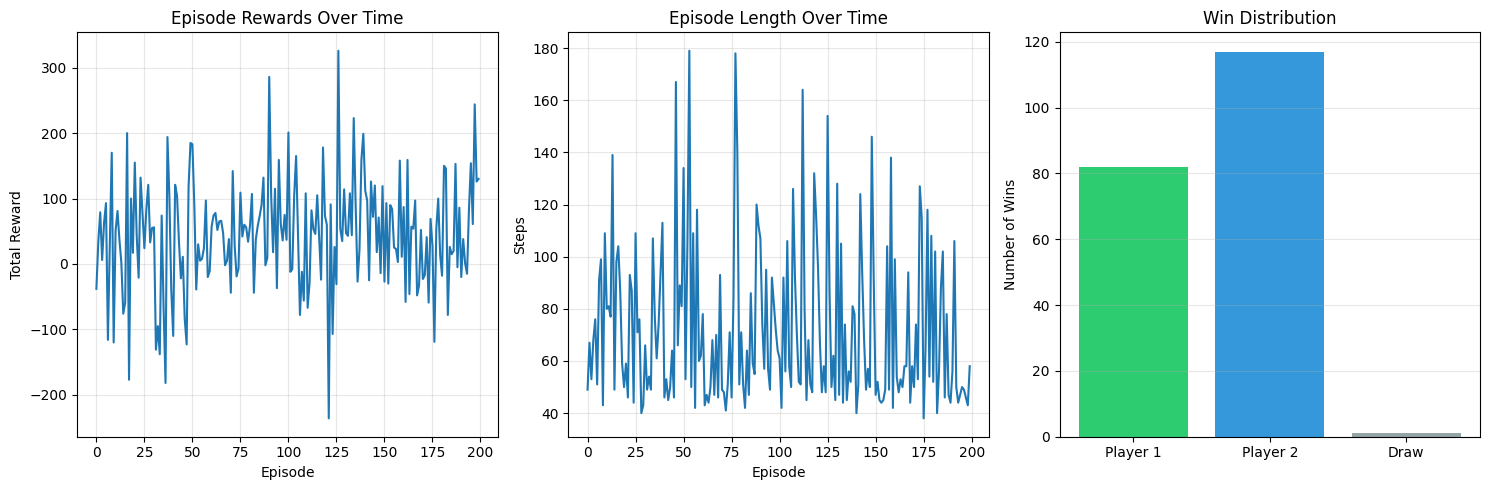



[3] Demonstration Game
Playing a demonstration game with trained agents...

DEMONSTRATION GAME: Trained Agents Playing

Current Player: 1
Scores - Player 1: 0 | Player 2: 0
   0   1   2   3   4   5   6   7
0 ↓ 2  .  ↓-5  .  ↓ 8  .  ↓-11 .  
1  .  ↓-7  .  ↓10  .  ↓-3  .  ↓ 0 
2 ↓ 4  .  ↓-1  .  ↓ 9  .  ↓-6  .  
3  .   .   .   .   .   .   .   .  
4  .   .   .   .   .   .   .   .  
5  .  ↑-9  .  ↑ 6  .  ↑-1  .  ↑ 4 
6 ↑ 0  .  ↑-3  .  ↑10  .  ↑-7  .  
7  .  ↑-11 .  ↑ 8  .  ↑-5  .  ↑ 2 


────────────────────────────────────────────────────────────────────────────────
Step 1: Agent 1 (Player 1)'s Turn
────────────────────────────────────────────────────────────────────────────────

Agent 1 (Player 1) Decision (Greedy):
  State value estimate: -0.017
  Number of legal moves: 7

Move selected: (2, 2) → (3, 1)
  ➡️  Simple move

Reward: 0

Current Player: 2
Scores - Player 1: 0 | Player 2: 0
   0   1   2   3   4   5   6   7
0 ↓ 2  .  ↓-5  .  ↓ 8  .  ↓-11 .  
1  .  ↓-7  .  ↓10  .  ↓-3  .  ↓ 0 

In [ ]:
# Main execution
if __name__ == "__main__":
    print("="*80)
    print("INTEGER DAMATH - ACTOR-CRITIC REINFORCEMENT LEARNING")
    print("="*80)
    print("\nThis implementation includes:")
    print("  ✓ Complete Integer Damath environment")
    print("  ✓ Actor-Critic neural network")
    print("  ✓ Detailed play-by-play logging")
    print("  ✓ Step-by-step analysis")
    print("  ✓ Move history tracking")
    print("  ✓ Comprehensive statistics")
    print("="*80)

    # Option 1: Analyze a single episode in detail
    print("\n[1] Single Episode Analysis")
    print("="*60)
    agent1 = ActorCriticAgent(lr=0.0003, name="Agent 1")
    agent2 = ActorCriticAgent(lr=0.0003, name="Agent 2")
    env, analysis = analyze_episode(agent1, agent2, episode_num=1)

    print("\n" + "="*80)

    # Option 2: Train with verbose episodes
    print("\n[2] Training with Verbose Episodes")
    print("="*60)
    print("Training agents with detailed output for episodes 1, 50, and 100...")

    agent1, agent2, env = train_actor_critic(
        num_episodes=200,
        render_every=50,
        verbose_episodes=[0, 49, 99]  # Episodes 1, 50, and 100
    )

    print("\n" + "="*80)

    # Option 3: Play demonstration game with full play-by-play
    print("\n[3] Demonstration Game")
    print("="*60)
    print("Playing a demonstration game with trained agents...")

    demo_env = play_demo_game(agent1, agent2, verbose=True)

    # Save the trained models
    agent1.save('damath_agent1.pth')
    agent2.save('damath_agent2.pth')
    print("\n✓ Models saved successfully!")
    print("="*80)